In [1]:
# Import pandas for loading and working with tabular data
import pandas as pd

# Import matplotlib for plotting
import matplotlib.pyplot as plt

# Import seaborn for statistical visualizations
import seaborn as sns


##Set plotting options for the notebook
# Use a clean seaborn style for plots
sns.set_style("whitegrid")

# Set a default figure size for matplotlib plots
plt.rcParams["figure.figsize"] = (10, 5)

In [2]:
# Read the final engineered dataset from the data folder
df_final = pd.read_csv("../data/df_final.csv", parse_dates=["timestamp"])

In [3]:
df_final.columns.tolist()


['timestamp',
 'price',
 'load',
 'wind_offshore',
 'wind_onshore',
 'solar',
 'hour',
 'day_of_week',
 'month',
 'temperature',
 'wind_speed',
 'is_weekend',
 'gas_price',
 'coal_price',
 'price_lag_24h',
 'price_lag_168h',
 'price_rolling_24h',
 'price_rolling_168h',
 'co2_price',
 'is_holiday',
 'is_hol_or_week',
 'total_generation',
 'net_export',
 'coal_generation',
 'gas_generation',
 'nuclear_generation',
 'actual_wind_offshore',
 'actual_wind_onshore',
 'actual_solar',
 'actual_load']

Inspect the loaded dataset

In [4]:
# Display the size of the DataFrame as (rows, columns)
print(df_final.shape)

# Display the column names
print(df_final.columns.tolist())

# Display the first 5 rows
display(df_final.head())

# Display the data types of all columns
print(df_final.dtypes)

# Count missing values in each column
print(df_final.isnull().sum())

(62728, 30)
['timestamp', 'price', 'load', 'wind_offshore', 'wind_onshore', 'solar', 'hour', 'day_of_week', 'month', 'temperature', 'wind_speed', 'is_weekend', 'gas_price', 'coal_price', 'price_lag_24h', 'price_lag_168h', 'price_rolling_24h', 'price_rolling_168h', 'co2_price', 'is_holiday', 'is_hol_or_week', 'total_generation', 'net_export', 'coal_generation', 'gas_generation', 'nuclear_generation', 'actual_wind_offshore', 'actual_wind_onshore', 'actual_solar', 'actual_load']


,timestamp,price,load,wind_offshore,wind_onshore,solar,hour,day_of_week,month,temperature,...,is_hol_or_week,total_generation,net_export,coal_generation,gas_generation,nuclear_generation,actual_wind_offshore,actual_wind_onshore,actual_solar,actual_load
0,2019-01-08 00:00:00,17.94,51472.75,4520.75,32832.00,0.0,0,1,1,5.0000,...,False,68405.50,13001.0,10497.25,3789.00,8675.50,3505.75,33982.00,0.0,54342.75
1,2019-01-08 01:00:00,20.91,49815.00,4397.00,33236.50,0.0,1,1,1,5.1250,...,False,68068.25,13461.0,10096.25,3614.00,8958.50,3552.00,33866.00,0.0,52541.75
2,2019-01-08 02:00:00,7.78,49241.75,4379.00,33473.50,0.0,2,1,1,4.9875,...,False,67413.75,13093.0,9980.50,3599.00,8720.75,3463.75,33839.50,0.0,51658.75
3,2019-01-08 03:00:00,14.33,49512.25,4134.75,33843.25,0.0,3,1,1,4.8625,...,False,68034.50,13258.0,9996.25,3709.75,8878.75,3473.25,34115.75,0.0,52231.75
4,2019-01-08 04:00:00,18.56,50572.75,3871.50,34549.75,0.0,4,1,1,4.8000,...,False,68487.00,13182.0,10178.50,3971.25,8970.75,3129.75,34217.25,0.0,53853.50


timestamp               datetime64[ns]
price                          float64
load                           float64
wind_offshore                  float64
wind_onshore                   float64
solar                          float64
hour                             int64
day_of_week                      int64
month                            int64
temperature                    float64
wind_speed                     float64
is_weekend                        bool
gas_price                      float64
coal_price                     float64
price_lag_24h                  float64
price_lag_168h                 float64
price_rolling_24h              float64
price_rolling_168h             float64
co2_price                      float64
is_holiday                        bool
is_hol_or_week                    bool
total_generation               float64
net_export                     float64
coal_generation                float64
gas_generation                 float64
nuclear_generation       

Inspect summary statistics of the target variable

In [5]:
# Display summary statistics of the day-ahead electricity price
print(df_final["price"].describe().round(2))

# Count how many hours have negative prices
negative_count = (df_final["price"] < 0).sum()
negative_share = (df_final["price"] < 0).mean()

print(f"\nNegative price hours: {negative_count}")
print(f"Share of negative price hours: {negative_share:.2%}")

count    62728.00
mean        95.12
std         92.90
min       -500.00
25%         38.10
50%         75.90
75%        115.27
max        936.28
Name: price, dtype: float64

Negative price hours: 2037
Share of negative price hours: 3.25%


Plot the distribution of day-ahead electricity prices

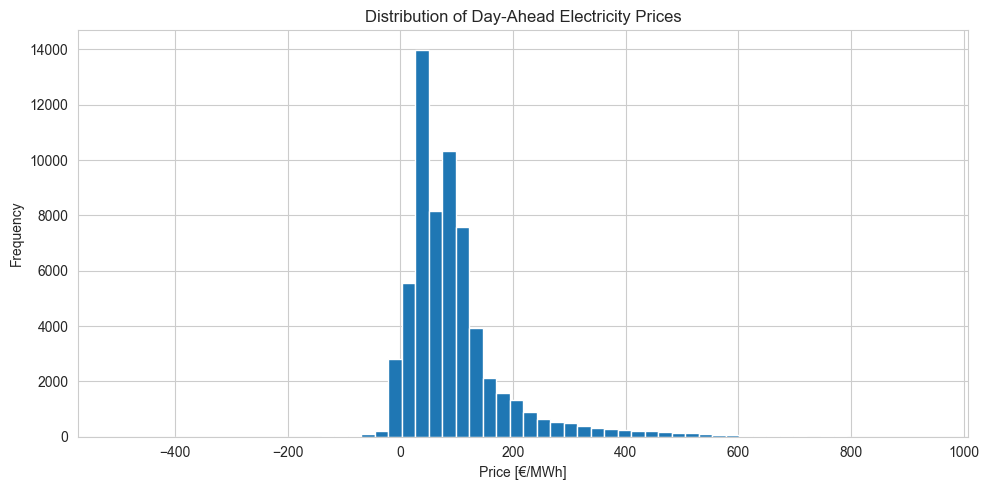

In [6]:
plt.figure(figsize=(10, 5))
plt.hist(df_final["price"], bins=60)
plt.title("Distribution of Day-Ahead Electricity Prices")
plt.xlabel("Price [€/MWh]")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

Plot a boxplot of day-ahead electricity prices

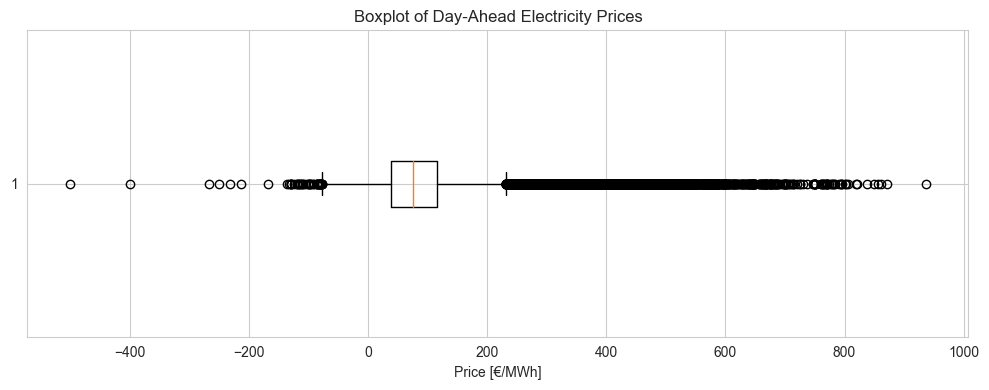

In [7]:
plt.figure(figsize=(10, 4))
plt.boxplot(df_final["price"], vert=False)
plt.title("Boxplot of Day-Ahead Electricity Prices")
plt.xlabel("Price [€/MWh]")
plt.tight_layout()
plt.show()

Plot a correlation heatmap of selected features

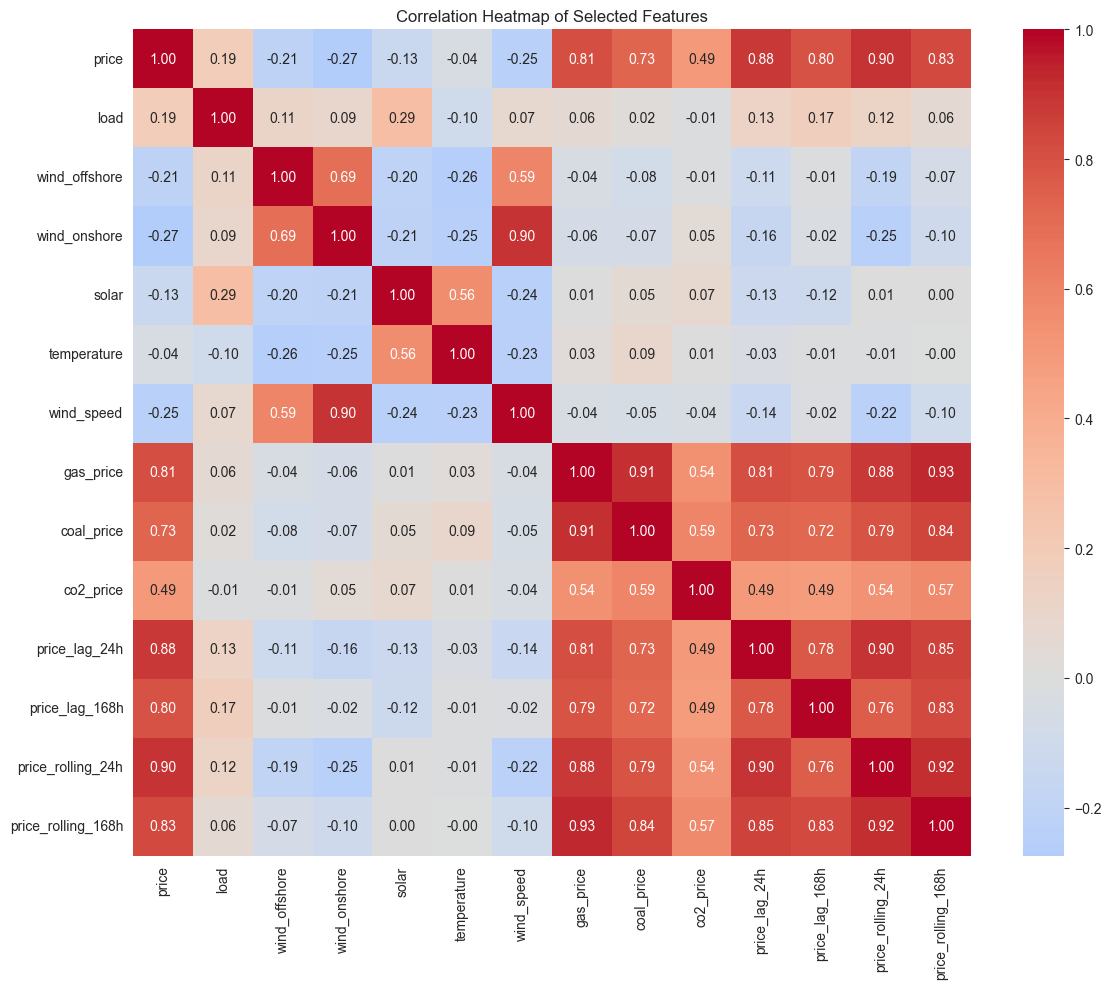

In [8]:
selected_cols = [
    "price", "load", "wind_offshore", "wind_onshore", "solar",
    "temperature", "wind_speed", "gas_price", "coal_price", "co2_price",
    "price_lag_24h", "price_lag_168h", "price_rolling_24h", "price_rolling_168h"
]

corr = df_final[selected_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap of Selected Features")
plt.tight_layout()
plt.show()

Plot day-ahead electricity prices over time

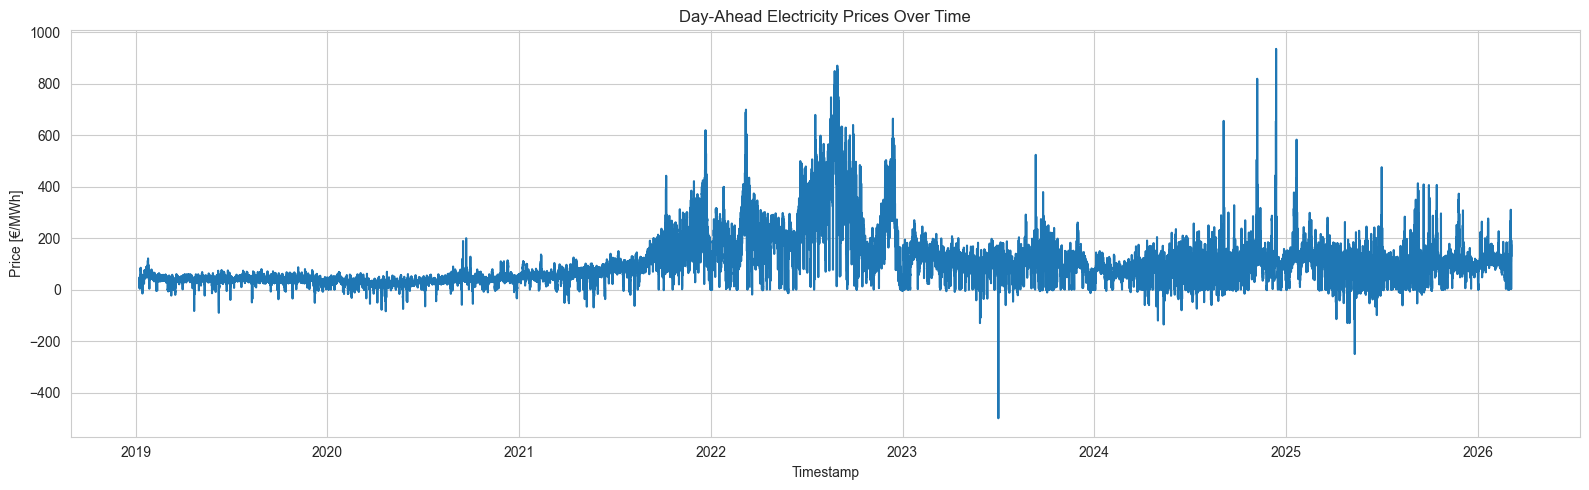

In [9]:
plt.figure(figsize=(16, 5))
plt.plot(df_final["timestamp"], df_final["price"])
plt.title("Day-Ahead Electricity Prices Over Time")
plt.xlabel("Timestamp")
plt.ylabel("Price [€/MWh]")
plt.tight_layout()
plt.show()

Analyze average electricity price by hour of day

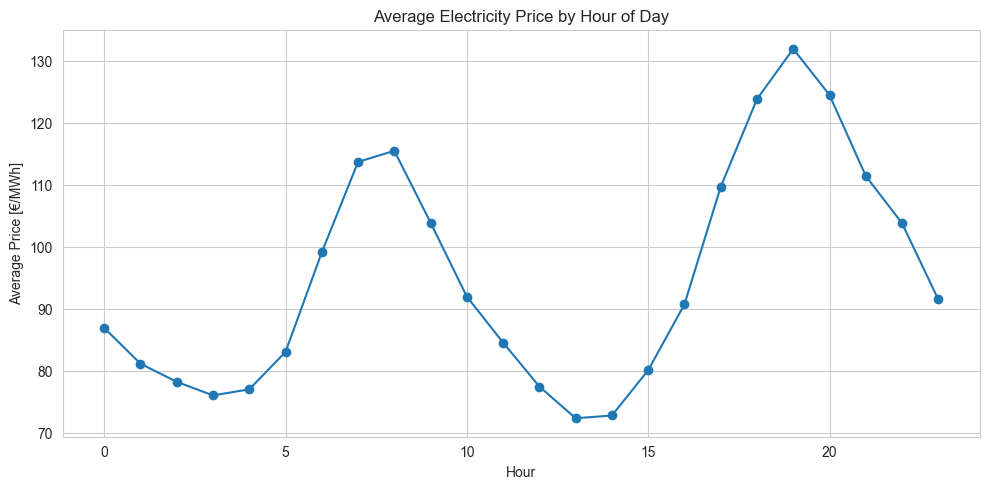

In [10]:
hourly_price = df_final.groupby("hour")["price"].mean()

plt.figure(figsize=(10, 5))
plt.plot(hourly_price.index, hourly_price.values, marker="o")
plt.title("Average Electricity Price by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Average Price [€/MWh]")
plt.grid(True)
plt.tight_layout()
plt.show()

Analyze average electricity price by day of week

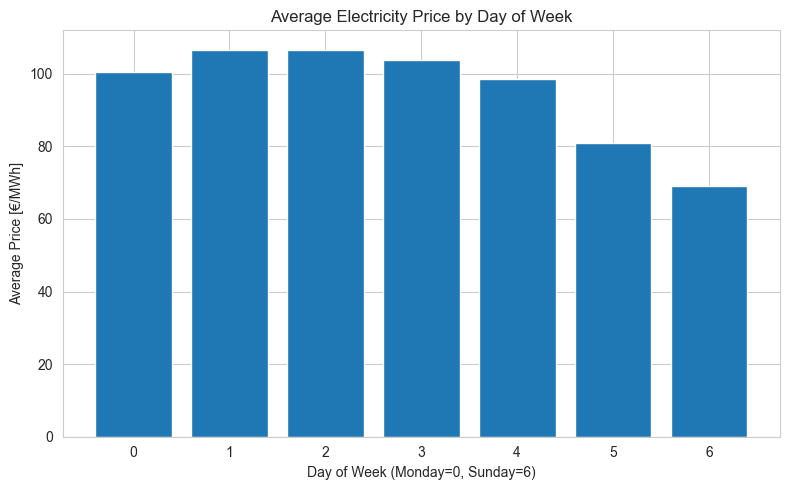

In [11]:
dow_price = df_final.groupby("day_of_week")["price"].mean()

plt.figure(figsize=(8, 5))
plt.bar(dow_price.index, dow_price.values)
plt.title("Average Electricity Price by Day of Week")
plt.xlabel("Day of Week (Monday=0, Sunday=6)")
plt.ylabel("Average Price [€/MWh]")
plt.tight_layout()
plt.show()

Analyze average electricity price by month

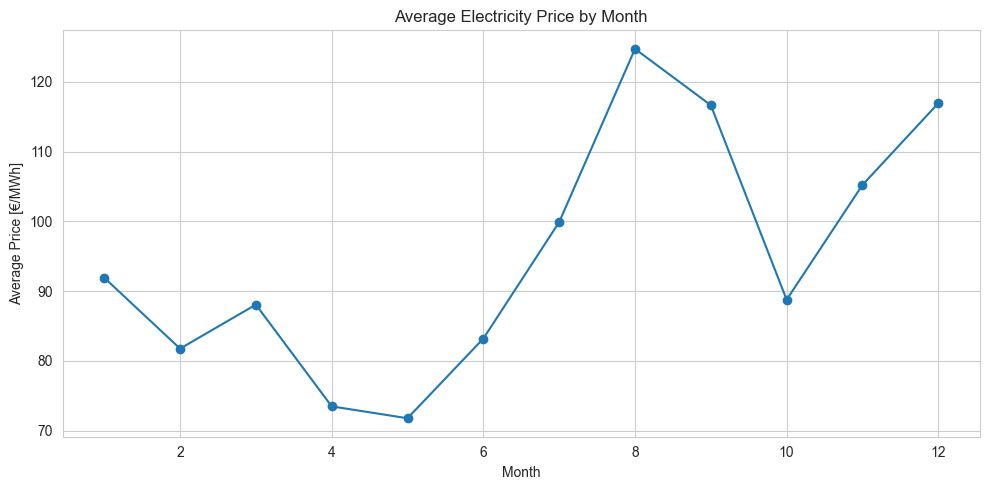

In [12]:
monthly_price = df_final.groupby("month")["price"].mean()

plt.figure(figsize=(10, 5))
plt.plot(monthly_price.index, monthly_price.values, marker="o")
plt.title("Average Electricity Price by Month")
plt.xlabel("Month")
plt.ylabel("Average Price [€/MWh]")
plt.grid(True)
plt.tight_layout()
plt.show()

Compare average prices for weekdays, weekends, and holidays

            count    mean    std     min    25%    50%     75%     max
day_type                                                              
Weekday   43559.0  104.75  97.49  -83.94  43.66  82.06  123.40  936.28
Weekend   17657.0   74.70  78.14 -500.00  27.79  58.04  100.10  704.62
Holiday    1512.0   56.01  62.11 -129.99  11.94  43.18   88.54  466.62


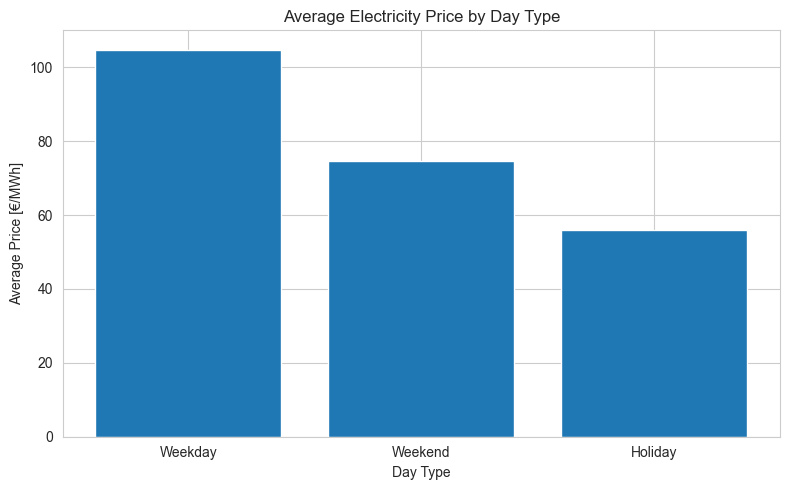

In [13]:
# Create a new category column for calendar type
df_final["day_type"] = "Weekday"
df_final.loc[df_final["is_weekend"], "day_type"] = "Weekend"
df_final.loc[df_final["is_holiday"], "day_type"] = "Holiday"

# Define the display order
order = ["Weekday", "Weekend", "Holiday"]

# Calculate summary statistics for each day type
day_type_stats = df_final.groupby("day_type")["price"].describe().reindex(order).round(2)

# Display the summary statistics
print(day_type_stats)

# Calculate the average price for each day type
avg_price_by_day_type = df_final.groupby("day_type")["price"].mean().reindex(order)

# Plot the average price by day type
plt.figure(figsize=(8, 5))
plt.bar(avg_price_by_day_type.index, avg_price_by_day_type.values)
plt.title("Average Electricity Price by Day Type")
plt.xlabel("Day Type")
plt.ylabel("Average Price [€/MWh]")
plt.tight_layout()
plt.show()

Analyze the relationship between electricity price and load

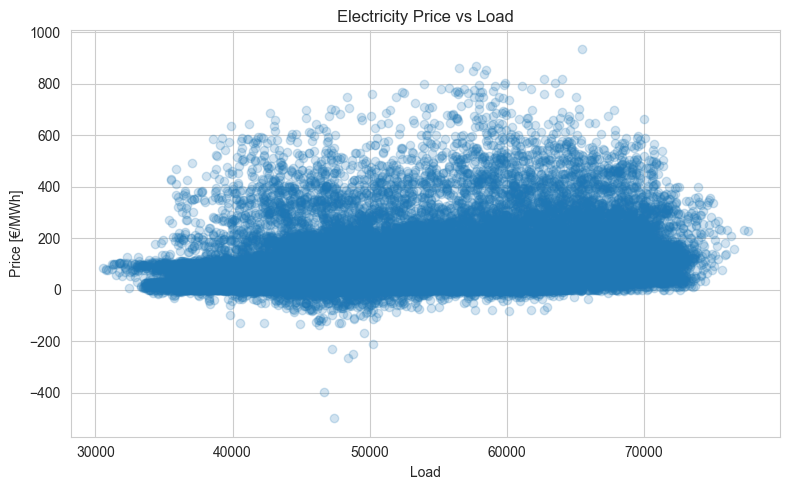

       price  load
price   1.00  0.19
load    0.19  1.00


In [14]:
plt.figure(figsize=(8, 5))
plt.scatter(df_final["load"], df_final["price"], alpha=0.2)
plt.title("Electricity Price vs Load")
plt.xlabel("Load")
plt.ylabel("Price [€/MWh]")
plt.tight_layout()
plt.show()

print(df_final[["price", "load"]].corr().round(2))

Analyze the relationship between price and renewable generation

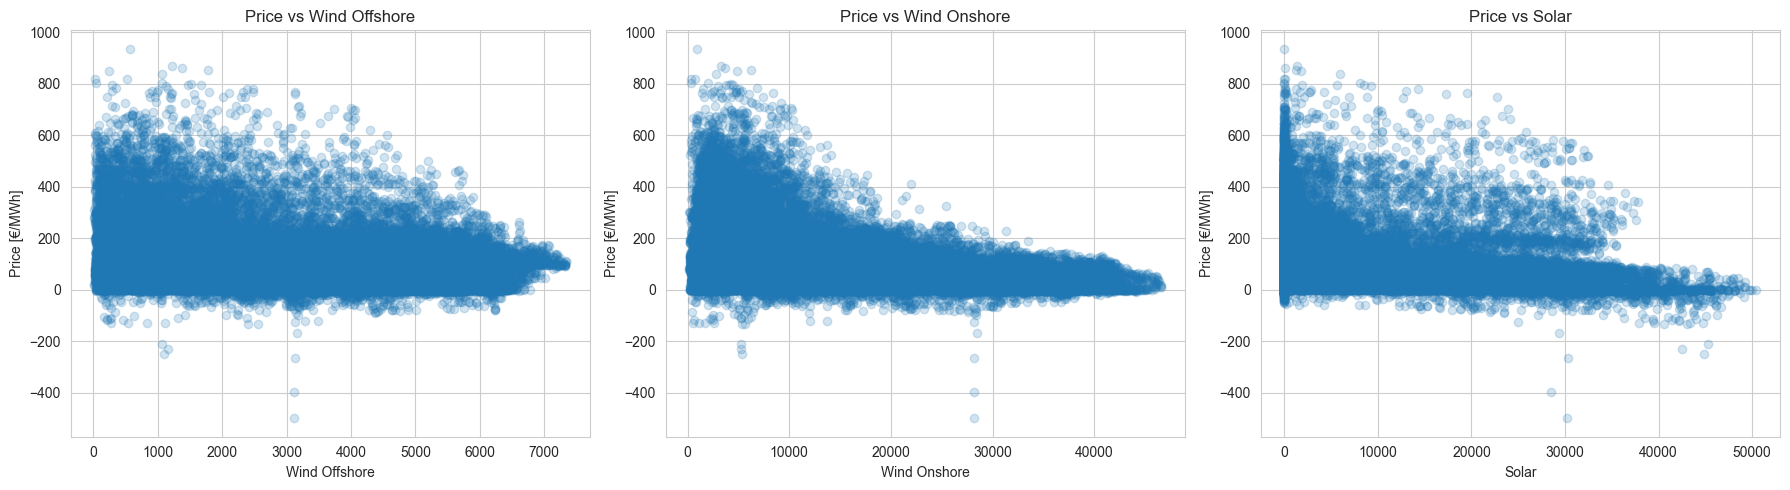

               price  wind_offshore  wind_onshore  solar
price           1.00          -0.21         -0.27  -0.13
wind_offshore  -0.21           1.00          0.69  -0.20
wind_onshore   -0.27           0.69          1.00  -0.21
solar          -0.13          -0.20         -0.21   1.00


In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(df_final["wind_offshore"], df_final["price"], alpha=0.2)
axes[0].set_title("Price vs Wind Offshore")
axes[0].set_xlabel("Wind Offshore")
axes[0].set_ylabel("Price [€/MWh]")

axes[1].scatter(df_final["wind_onshore"], df_final["price"], alpha=0.2)
axes[1].set_title("Price vs Wind Onshore")
axes[1].set_xlabel("Wind Onshore")
axes[1].set_ylabel("Price [€/MWh]")

axes[2].scatter(df_final["solar"], df_final["price"], alpha=0.2)
axes[2].set_title("Price vs Solar")
axes[2].set_xlabel("Solar")
axes[2].set_ylabel("Price [€/MWh]")

plt.tight_layout()
plt.show()

print(df_final[["price", "wind_offshore", "wind_onshore", "solar"]].corr().round(2))

Analyze the relationship between price and weather features

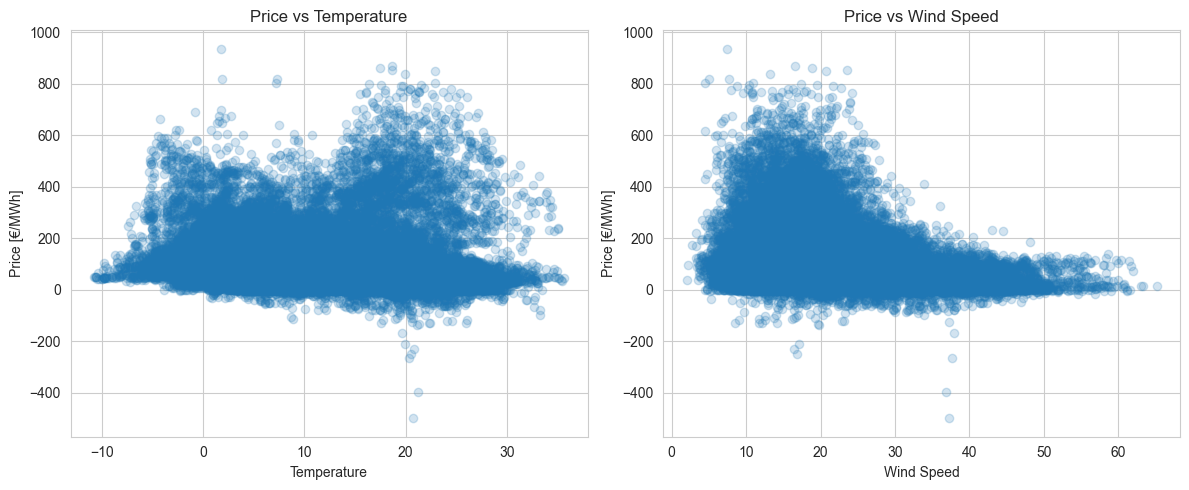

             price  temperature  wind_speed
price         1.00        -0.04       -0.25
temperature  -0.04         1.00       -0.23
wind_speed   -0.25        -0.23        1.00


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(df_final["temperature"], df_final["price"], alpha=0.2)
axes[0].set_title("Price vs Temperature")
axes[0].set_xlabel("Temperature")
axes[0].set_ylabel("Price [€/MWh]")

axes[1].scatter(df_final["wind_speed"], df_final["price"], alpha=0.2)
axes[1].set_title("Price vs Wind Speed")
axes[1].set_xlabel("Wind Speed")
axes[1].set_ylabel("Price [€/MWh]")

plt.tight_layout()
plt.show()

print(df_final[["price", "temperature", "wind_speed"]].corr().round(2))

Analyze the relationship between price and commodity market features

C:\Users\atefe\AppData\Local\Temp\ipykernel_35756\3697045558.py:18: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from current font.
  plt.tight_layout()
c:\Users\atefe\Documents\Bootcamp\Capstone\WattWise\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


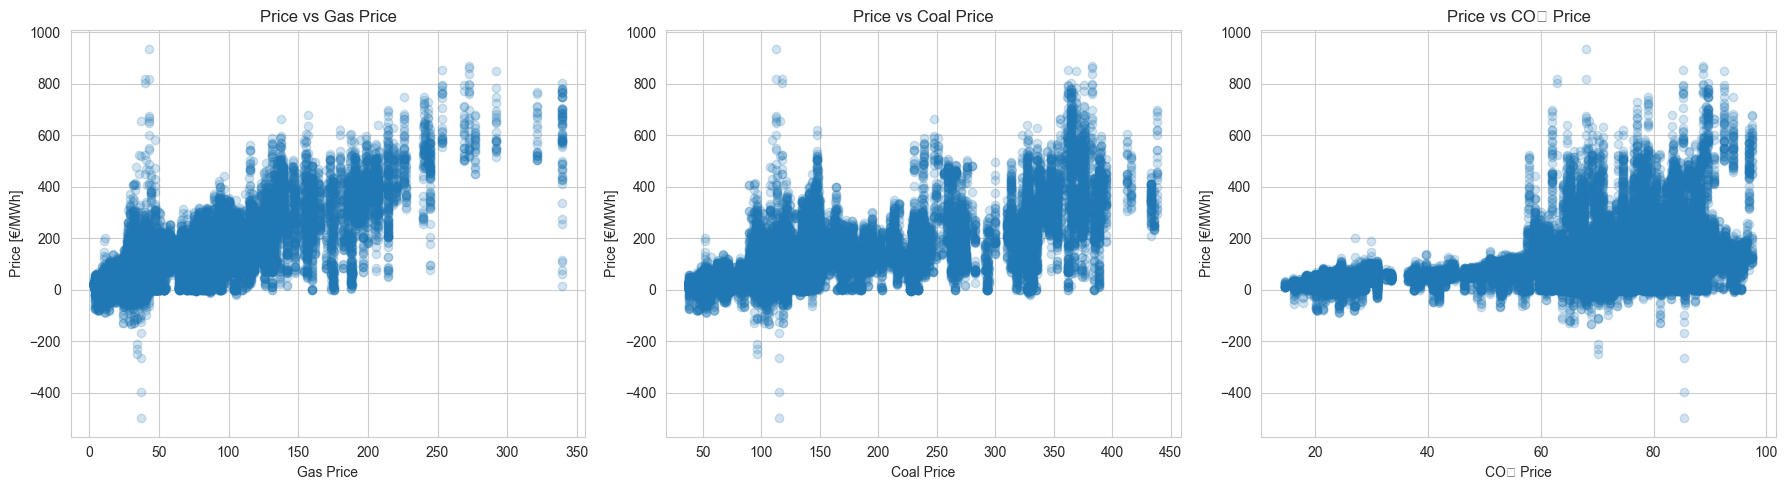

            price  gas_price  coal_price  co2_price
price        1.00       0.81        0.73       0.49
gas_price    0.81       1.00        0.91       0.54
coal_price   0.73       0.91        1.00       0.59
co2_price    0.49       0.54        0.59       1.00


In [17]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(df_final["gas_price"], df_final["price"], alpha=0.2)
axes[0].set_title("Price vs Gas Price")
axes[0].set_xlabel("Gas Price")
axes[0].set_ylabel("Price [€/MWh]")

axes[1].scatter(df_final["coal_price"], df_final["price"], alpha=0.2)
axes[1].set_title("Price vs Coal Price")
axes[1].set_xlabel("Coal Price")
axes[1].set_ylabel("Price [€/MWh]")

axes[2].scatter(df_final["co2_price"], df_final["price"], alpha=0.2)
axes[2].set_title("Price vs CO₂ Price")
axes[2].set_xlabel("CO₂ Price")
axes[2].set_ylabel("Price [€/MWh]")

plt.tight_layout()
plt.show()

print(df_final[["price", "gas_price", "coal_price", "co2_price"]].corr().round(2))

Analyze lag and rolling price features

In [18]:
lag_features = [
    "price",
    "price_lag_24h",
    "price_lag_168h",
    "price_rolling_24h",
    "price_rolling_168h"
]

print(df_final[lag_features].corr().round(2))

                    price  price_lag_24h  price_lag_168h  price_rolling_24h   
price                1.00           0.88            0.80               0.90  \
price_lag_24h        0.88           1.00            0.78               0.90   
price_lag_168h       0.80           0.78            1.00               0.76   
price_rolling_24h    0.90           0.90            0.76               1.00   
price_rolling_168h   0.83           0.85            0.83               0.92   

                    price_rolling_168h  
price                             0.83  
price_lag_24h                     0.85  
price_lag_168h                    0.83  
price_rolling_24h                 0.92  
price_rolling_168h                1.00  


Analyze negative electricity price periods

In [19]:
negative_prices = df_final[df_final["price"] < 0]

print(f"Number of negative price hours: {len(negative_prices)}")
print(f"Share of negative price hours: {len(negative_prices) / len(df_final):.2%}")

print("\nSample of negative price hours:")
print(negative_prices[["timestamp", "price"]].head(10))

Number of negative price hours: 2037
Share of negative price hours: 3.25%

Sample of negative price hours:
              timestamp  price
134 2019-01-13 14:00:00  -0.08
135 2019-01-13 15:00:00  -0.01
136 2019-01-13 16:00:00  -0.27
140 2019-01-13 20:00:00  -0.02
141 2019-01-13 21:00:00  -0.33
143 2019-01-13 23:00:00  -7.28
144 2019-01-14 00:00:00  -3.14
145 2019-01-14 01:00:00 -12.00
146 2019-01-14 02:00:00 -15.04
147 2019-01-14 03:00:00 -11.09


Compare feature averages for negative and non-negative price hours

In [20]:
df_final["negative_price"] = df_final["price"] < 0

comparison = df_final.groupby("negative_price")[[
    "price", "load", "wind_offshore", "wind_onshore", "solar",
    "temperature", "wind_speed", "gas_price", "coal_price", "co2_price"
]].mean().round(2)

print(comparison)

                price      load  wind_offshore  wind_onshore     solar   
negative_price                                                           
False           98.73  54452.81        2883.57      11626.74   5696.51  \
True           -12.59  49612.52        3416.51      21192.43  20556.01   

                temperature  wind_speed  gas_price  coal_price  co2_price  
negative_price                                                             
False                 10.49       20.64      45.38      123.05      58.40  
True                  16.09       28.13      30.85      100.56      59.13  


Analyze average electricity price by year

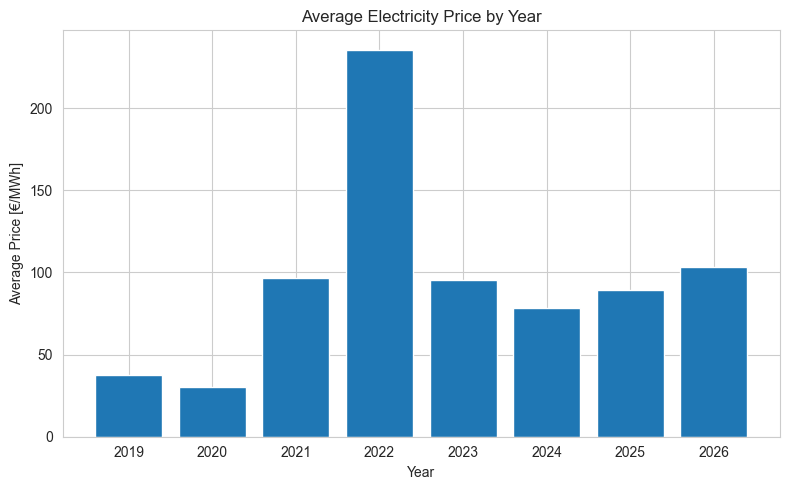

In [21]:
df_final["year"] = df_final["timestamp"].dt.year
yearly_price = df_final.groupby("year")["price"].mean()

plt.figure(figsize=(8, 5))
plt.bar(yearly_price.index, yearly_price.values)
plt.title("Average Electricity Price by Year")
plt.xlabel("Year")
plt.ylabel("Average Price [€/MWh]")
plt.tight_layout()
plt.show()

------------------------------------------------------------------------------

Day-ahead electricity prices over time

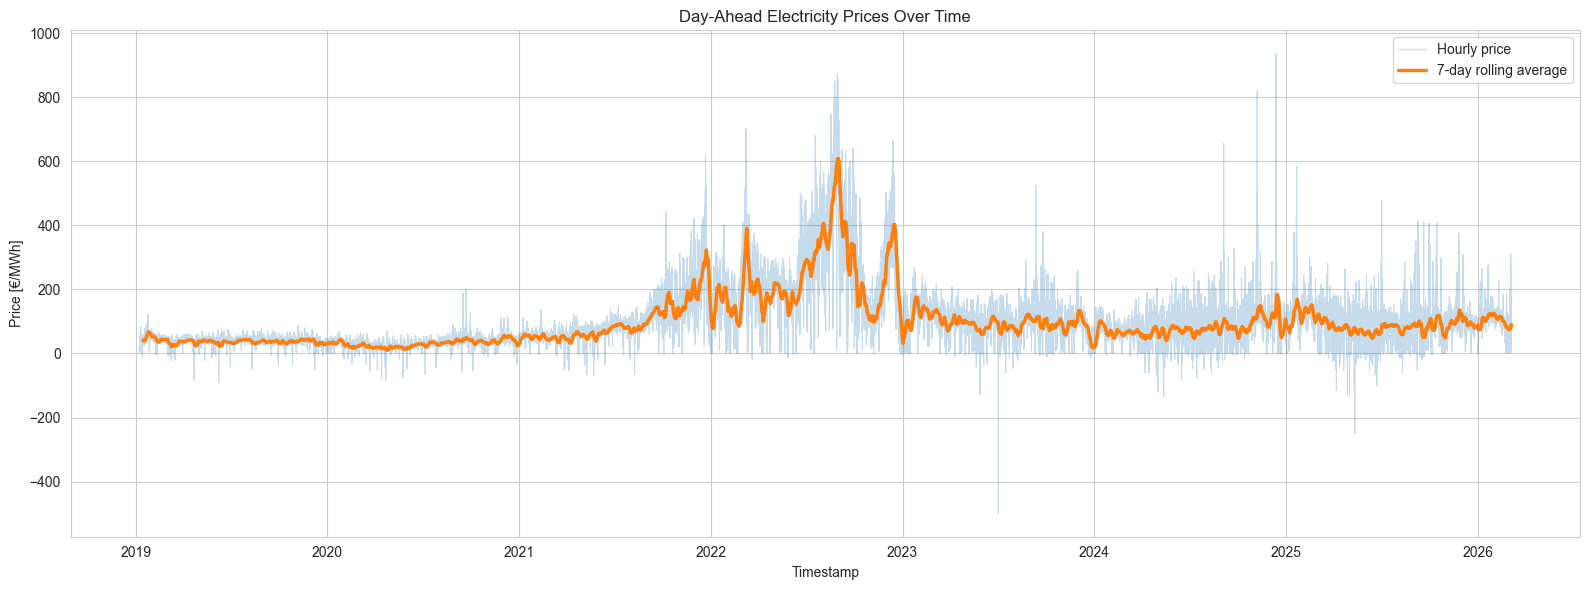

In [22]:
# Create a 7-day rolling average of the price
df_final["price_rolling_7d"] = df_final["price"].rolling(24 * 7).mean()

# Plot hourly price and rolling average
plt.figure(figsize=(16, 6))
plt.plot(df_final["timestamp"], df_final["price"], alpha=0.25, linewidth=0.8, label="Hourly price")
plt.plot(df_final["timestamp"], df_final["price_rolling_7d"], linewidth=2.5, label="7-day rolling average")

plt.title("Day-Ahead Electricity Prices Over Time")
plt.xlabel("Timestamp")
plt.ylabel("Price [€/MWh]")
plt.legend()
plt.tight_layout()
plt.show()

Monthly and hourly electricity price pattern

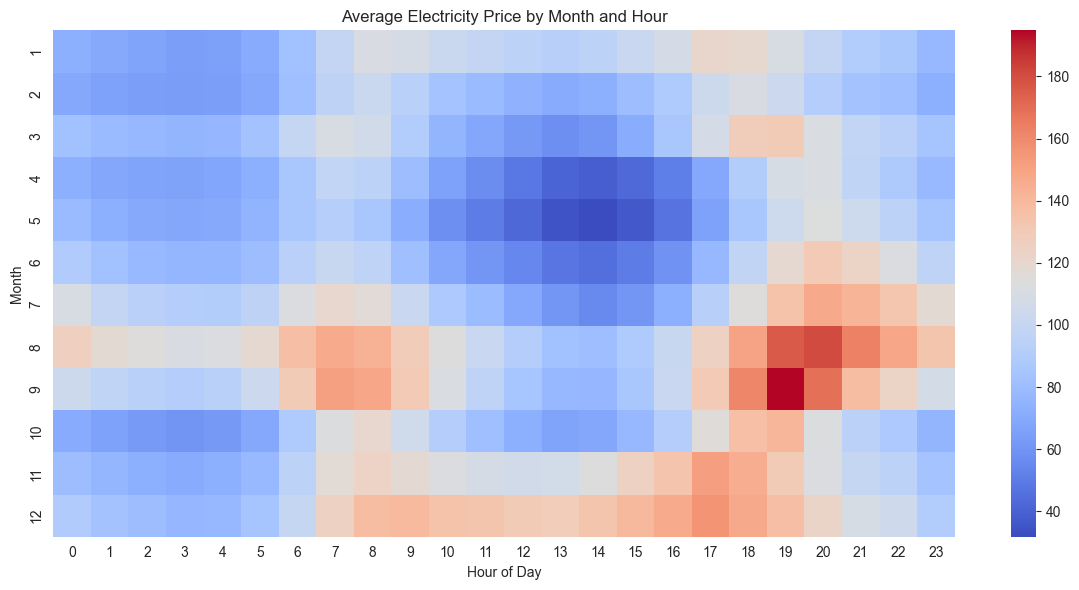

In [23]:
# Create a pivot table with month and hour
price_pivot = df_final.pivot_table(
    values="price",
    index="month",
    columns="hour",
    aggfunc="mean"
)

plt.figure(figsize=(12, 6))
sns.heatmap(price_pivot, cmap="coolwarm", annot=False)

plt.title("Average Electricity Price by Month and Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Month")
plt.tight_layout()
plt.show()

Negative price frequency by hour

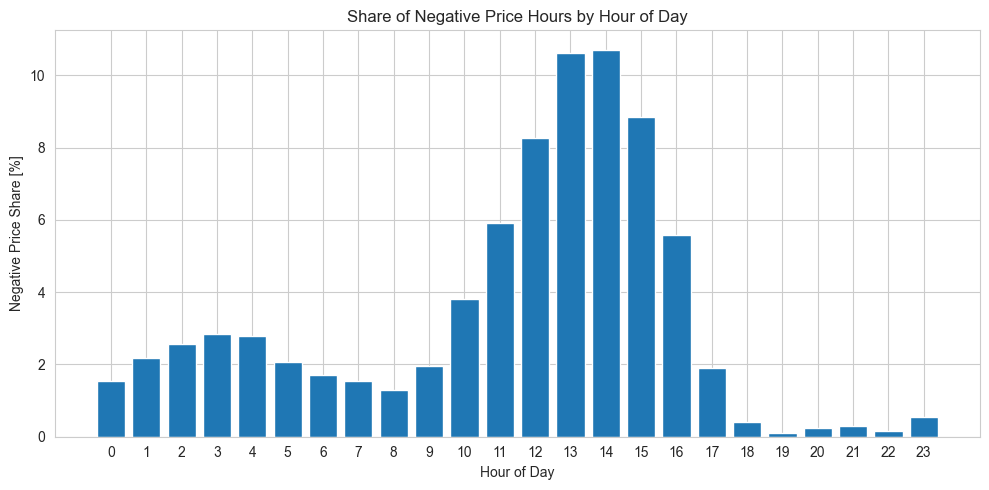

In [24]:
# Create a binary negative-price indicator
df_final["negative_price"] = df_final["price"] < 0

# Calculate share of negative price hours by hour
negative_share_by_hour = df_final.groupby("hour")["negative_price"].mean() * 100

plt.figure(figsize=(10, 5))
plt.bar(negative_share_by_hour.index, negative_share_by_hour.values)

plt.title("Share of Negative Price Hours by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Negative Price Share [%]")
plt.xticks(range(0, 24))
plt.tight_layout()
plt.show()

System conditions during negative and non-negative price hours

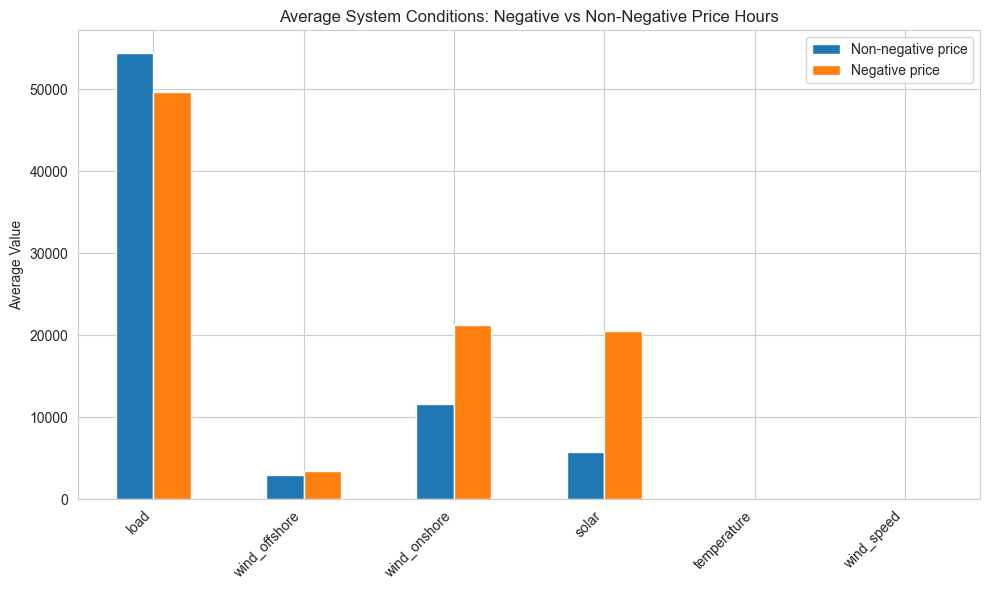

In [25]:
comparison = df_final.groupby("negative_price")[[
    "load", "wind_offshore", "wind_onshore", "solar",
    "temperature", "wind_speed"
]].mean().T

comparison.columns = ["Non-negative price", "Negative price"]

comparison.plot(kind="bar", figsize=(10, 6))
plt.title("Average System Conditions: Negative vs Non-Negative Price Hours") #Average Load and Renewable Generation by Price Regime
plt.ylabel("Average Value")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

Compare weather conditions during negative and non-negative price hours

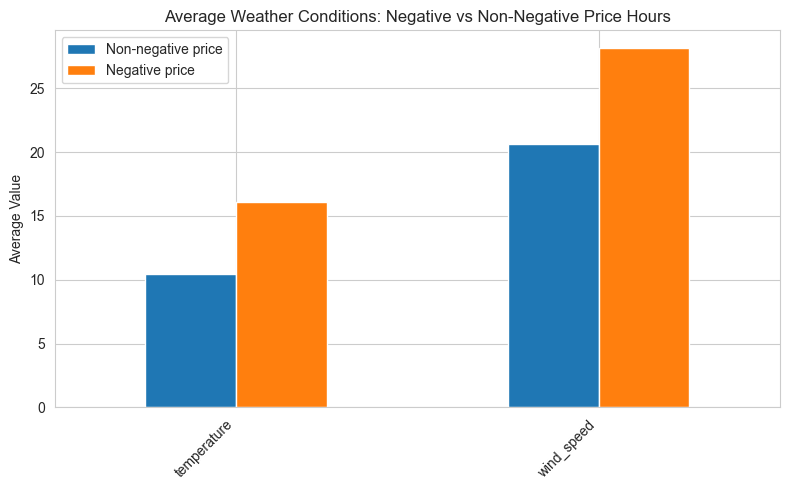

In [26]:
# Calculate average values for negative and non-negative price hours
comparison_weather = df_final.groupby("negative_price")[[
    "temperature", "wind_speed"
]].mean().T

comparison_weather.columns = ["Non-negative price", "Negative price"]

# Plot weather-related variables
comparison_weather.plot(kind="bar", figsize=(8, 5))
plt.title("Average Weather Conditions: Negative vs Non-Negative Price Hours")
plt.ylabel("Average Value")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

Compare average electricity price across wind onshore, wind offshore, and solar levels

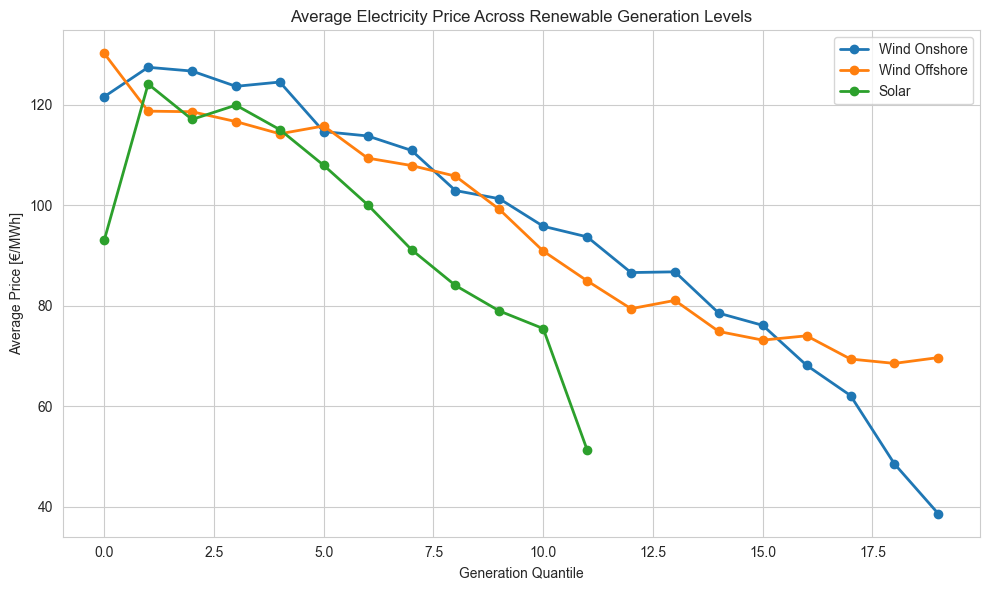

In [27]:
# Create a copy of the DataFrame
df_temp = df_final.copy()

# Create quantile bins for each renewable feature
df_temp["wind_onshore_bin"] = pd.qcut(df_temp["wind_onshore"], q=20, duplicates="drop")
df_temp["wind_offshore_bin"] = pd.qcut(df_temp["wind_offshore"], q=20, duplicates="drop")
df_temp["solar_bin"] = pd.qcut(df_temp["solar"], q=20, duplicates="drop")

# Calculate average price for each bin
wind_onshore_price = df_temp.groupby("wind_onshore_bin")["price"].mean()
wind_offshore_price = df_temp.groupby("wind_offshore_bin")["price"].mean()
solar_price = df_temp.groupby("solar_bin")["price"].mean()

# Plot all three trends
plt.figure(figsize=(10, 6))

plt.plot(range(len(wind_onshore_price)), wind_onshore_price.values, marker="o", linewidth=2, label="Wind Onshore")
plt.plot(range(len(wind_offshore_price)), wind_offshore_price.values, marker="o", linewidth=2, label="Wind Offshore")
plt.plot(range(len(solar_price)), solar_price.values, marker="o", linewidth=2, label="Solar")

plt.title("Average Electricity Price Across Renewable Generation Levels")
plt.xlabel("Generation Quantile")
plt.ylabel("Average Price [€/MWh]")
plt.legend()
plt.tight_layout()
plt.show()

Electricity price as a function of load

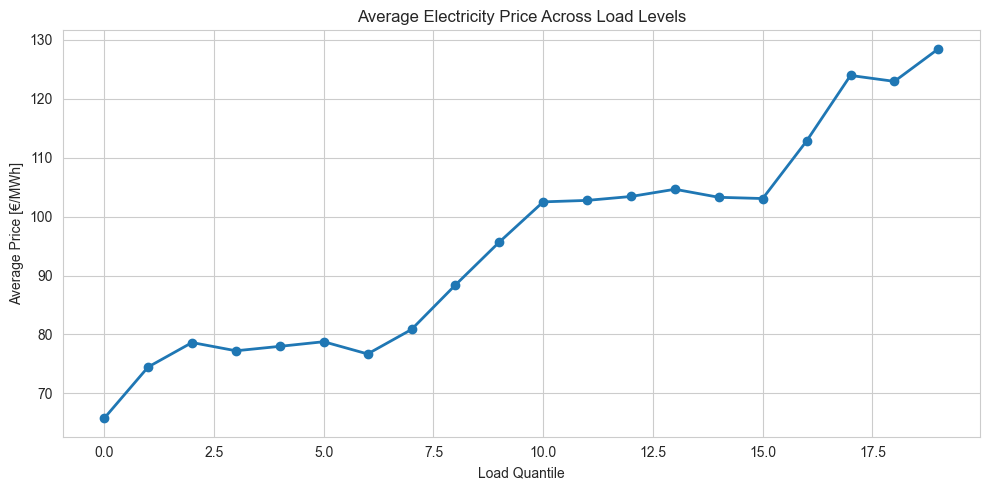

In [28]:
# Create bins for load
df_temp = df_final.copy()
df_temp["load_bin"] = pd.qcut(df_temp["load"], q=20, duplicates="drop")

# Calculate average price per load bin
load_bin_price = df_temp.groupby("load_bin")["price"].mean()

plt.figure(figsize=(10, 5))
plt.plot(range(len(load_bin_price)), load_bin_price.values, marker="o", linewidth=2)

plt.title("Average Electricity Price Across Load Levels")
plt.xlabel("Load Quantile")
plt.ylabel("Average Price [€/MWh]")
plt.tight_layout()
plt.show()

Annual average market drivers and electricity price

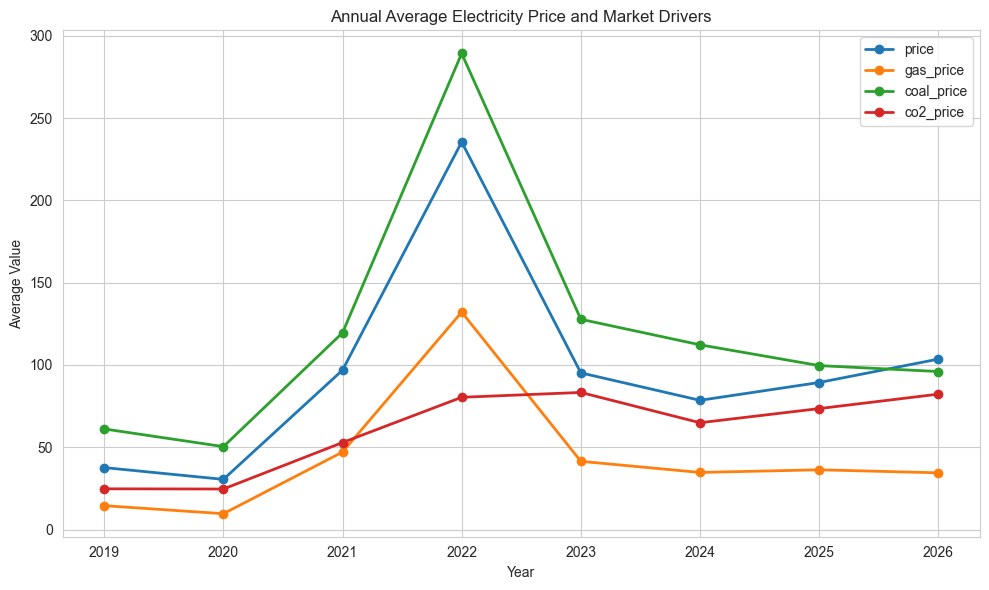

In [29]:
# Create a year column
df_final["year"] = df_final["timestamp"].dt.year

annual_means = df_final.groupby("year")[[
    "price", "gas_price", "coal_price", "co2_price"
]].mean()

plt.figure(figsize=(10, 6))
for col in annual_means.columns:
    plt.plot(annual_means.index, annual_means[col], marker="o", linewidth=2, label=col)

plt.title("Annual Average Electricity Price and Market Drivers")
plt.xlabel("Year")
plt.ylabel("Average Value")
plt.legend()
plt.tight_layout()
plt.show()

Distribution of electricity prices by month

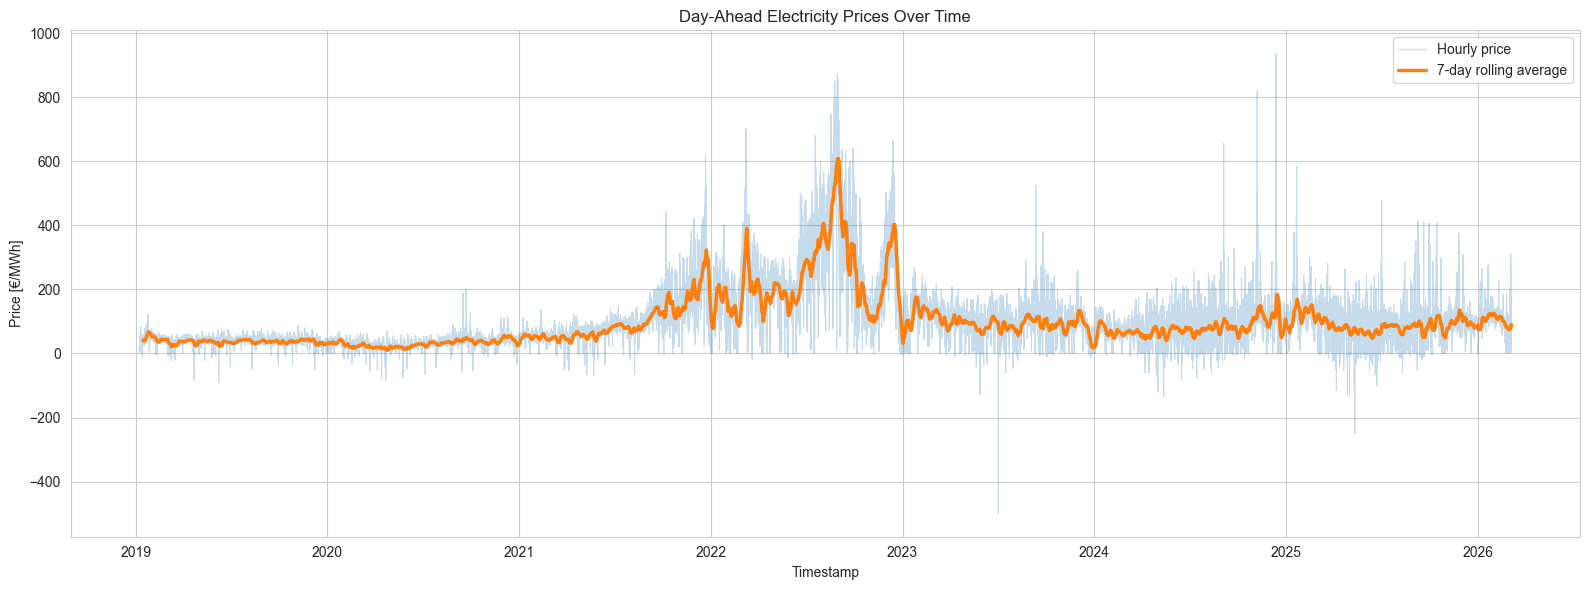

In [30]:
# Create a 7-day rolling average of the price
df_final["price_rolling_7d"] = df_final["price"].rolling(24 * 7).mean()

# Plot hourly price and rolling average
plt.figure(figsize=(16, 6))
plt.plot(df_final["timestamp"], df_final["price"], alpha=0.25, linewidth=0.8, label="Hourly price")
plt.plot(df_final["timestamp"], df_final["price_rolling_7d"], linewidth=2.5, label="7-day rolling average")

plt.title("Day-Ahead Electricity Prices Over Time")
plt.xlabel("Timestamp")
plt.ylabel("Price [€/MWh]")
plt.legend()
plt.tight_layout()
plt.show()

Share of negative price hours by year

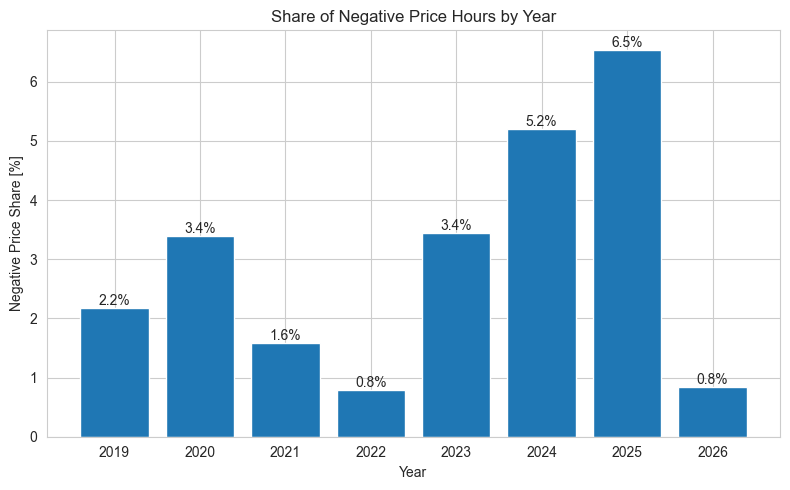

In [31]:
negative_share_by_year = df_final.groupby("year")["negative_price"].mean() * 100

plt.figure(figsize=(8, 5))
bars = plt.bar(negative_share_by_year.index, negative_share_by_year.values)

plt.title("Share of Negative Price Hours by Year")
plt.xlabel("Year")
plt.ylabel("Negative Price Share [%]")

for bar in bars:
    y = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, y, f"{y:.1f}%", ha="center", va="bottom")

plt.tight_layout()
plt.show()